In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score
from datetime import timedelta
from xgboost import XGBClassifier
import os
from scipy.stats import entropy
from scipy.stats import uniform, randint

import sys
init_dir = os.getcwd()

In [3]:
consumer_df = pd.read_parquet('../mlc/training_data/consumer_data.parquet')
transactions = pd.read_parquet('../mlc/training_data/transactions.parquet')

In [4]:
consumer_df['evaluation_date'] = pd.to_datetime(consumer_df['evaluation_date'])
transactions['posted_date'] = pd.to_datetime(transactions['posted_date'])

In [5]:
# Filter only consumer IDs of interest (C01)
consumer_df = consumer_df[consumer_df['masked_consumer_id'].str[2] == '1']
transactions = transactions[transactions['masked_consumer_id'].str[2] == '1']

In [6]:
# Step 1: Filter transactions to only those before or on the evaluation date
transactions_df = transactions.merge(
    consumer_df[['masked_consumer_id', 'evaluation_date']],
    on='masked_consumer_id',
    how='left'
)
transactions_df = transactions_df[transactions_df['posted_date'] < transactions_df['evaluation_date']]

In [7]:
consumer_df

,evaluation_date,FPF_TARGET,total_balance,masked_consumer_id
0,2021-08-26,0.0,1380.84,C01100001
1,2022-08-02,0.0,20163.90,C01100002
2,2021-03-04,0.0,3986.25,C01100003
3,2022-11-19,0.0,5956.03,C01100004
4,2021-11-21,0.0,29421.10,C01100005
...,...,...,...,...
4995,2023-02-01,0.0,48582.14,C01104996
4996,2021-07-15,0.0,11567.65,C01104997
4997,2021-11-08,0.0,1135.38,C01104998
4998,2021-09-20,0.0,4987.83,C01104999


In [8]:
transactions_df

,masked_consumer_id,posted_date,amount,category,masked_transaction_id,evaluation_date
0,C01103696,2022-05-02,400.00,1.0,C01T04156275,2022-09-15
1,C01103696,2022-06-09,38.00,1.0,C01T04156276,2022-09-15
2,C01103696,2022-08-13,4.00,6.0,C01T04156277,2022-09-15
3,C01103696,2022-09-13,0.17,7.0,C01T04156278,2022-09-15
4,C01103696,2022-02-24,2095.00,1.0,C01T04156279,2022-09-15
...,...,...,...,...,...,...
4477898,C01102466,2022-08-18,120.00,6.0,C01T02770845,2022-08-22
4477899,C01102466,2022-06-16,57.46,2.0,C01T02770846,2022-08-22
4477900,C01102466,2022-01-07,2273.99,5.0,C01T02770847,2022-08-22
4477901,C01102466,2022-08-08,35.14,2.0,C01T02770848,2022-08-22


In [9]:
# Split consumers BEFORE feature engineering
train_ids, val_ids = train_test_split(
    consumer_df['masked_consumer_id'],
    test_size=0.2,
    stratify=consumer_df['FPF_TARGET'],
    random_state=42
)

train_consumers = consumer_df[consumer_df['masked_consumer_id'].isin(train_ids)]
val_consumers = consumer_df[consumer_df['masked_consumer_id'].isin(val_ids)]

train_txns = transactions[transactions['masked_consumer_id'].isin(train_ids)]
val_txns = transactions[transactions['masked_consumer_id'].isin(val_ids)]


In [10]:
# Feature engineering
def aggregate_features(txns):
    # Create a copy of the DataFrame to avoid the warning
    txns = txns.copy()
    
    # Use .loc to properly set the new columns
    txns.loc[:, 'is_credit'] = txns['amount'] > 0
    txns.loc[:, 'is_debit'] = txns['amount'] < 0
    
    features = txns.groupby('masked_consumer_id').agg(
        total_amount=('amount', 'sum'),
        mean_amount=('amount', 'mean'),
        std_amount=('amount', 'std'),
        min_amount=('amount', 'min'),
        max_amount=('amount', 'max'),
        median_amount=('amount', 'median'),
        transaction_count=('amount', 'count'),
        credit_sum=('amount', lambda x: x[x > 0].sum()),
        debit_sum=('amount', lambda x: x[x < 0].sum())
    )
    return features

X_train_feats = aggregate_features(train_txns)
X_val_feats = aggregate_features(val_txns)

In [11]:
# Step 2: Feature Engineering
# Create debit/credit indicators
transactions_df['is_credit'] = transactions_df['amount'] > 0
transactions_df['is_debit'] = transactions_df['amount'] < 0

# Compute aggregate features
agg = transactions_df.groupby('masked_consumer_id').agg(
    total_amount=('amount', 'sum'),
    mean_amount=('amount', 'mean'),
    std_amount=('amount', 'std'),
    min_amount=('amount', 'min'),
    max_amount=('amount', 'max'),
    median_amount=('amount', 'median'),
    transaction_count=('amount', 'count'),
    credit_sum=('is_credit', lambda x: transactions_df.loc[x.index, 'amount'][x].sum()),
    debit_sum=('is_debit', lambda x: abs(transactions_df.loc[x.index, 'amount'][x].sum()))
)

# Ratio of credits to debits
agg['credit_debit_ratio'] = agg['credit_sum'] / agg['debit_sum'].replace(0, np.nan)
agg['credit_debit_ratio'] = agg['credit_debit_ratio'].fillna(0)

# Recent 30-day transaction features
transactions_df['days_before_eval'] = (transactions_df['evaluation_date'] - transactions_df['posted_date']).dt.days
recent_df = transactions_df[transactions_df['days_before_eval'] <= 30].groupby('masked_consumer_id').agg(
    recent30_sum=('amount', 'sum'),
    recent30_count=('amount', 'count')
)

# Monthly cashflow volatility: std / mean
transactions_df['month'] = transactions_df['posted_date'].dt.to_period('M')
monthly_cashflow = transactions_df.groupby(['masked_consumer_id', 'month'])['amount'].sum().reset_index()
monthly_stats = monthly_cashflow.groupby('masked_consumer_id')['amount'].agg(['mean', 'std']).rename(
    columns={'mean': 'monthly_mean', 'std': 'monthly_std'}
)
monthly_stats['monthly_cv'] = monthly_stats['monthly_std'] / monthly_stats['monthly_mean'].replace(0, np.nan)
monthly_stats = monthly_stats.fillna(0)

# category
cat_encode = pd.get_dummies(transactions_df, columns = ['category'], drop_first = False)
cat_encode.rename(columns = {f"category_{i}.0": f"category_{i}_mean" for i in range(36)}, inplace = True)
cat_encode_mean = cat_encode.groupby('masked_consumer_id').agg({f"category_{i}_mean": 'sum' for i in range(36)})


# weekend vs weekday transactions
transactions_df['weekday'] = transactions_df['posted_date'].dt.weekday
transactions_df['is_weekend'] = transactions_df['weekday'] >= 5

weekend_spend = transactions_df[transactions_df['amount'] > 0].groupby(['masked_consumer_id', 'is_weekend'])['amount'].sum().unstack(fill_value=0)
weekend_spend.columns = ['weekday_spending', 'weekend_spending']
weekend_spend['weekend_ratio'] = weekend_spend['weekend_spending'] / (weekend_spend['weekday_spending'] + 1e-6)

# Transaction frequency and span
txn_freq = transactions_df.groupby('masked_consumer_id').agg(
    unique_txn_days=('posted_date', lambda x: x.nunique()),
    txn_days_span=('posted_date', lambda x: (x.max() - x.min()).days + 1),
)
txn_freq['txn_per_day'] = txn_freq['unique_txn_days'] / txn_freq['txn_days_span'].replace(0, 1)

# percentiles of transaction amounts
percentiles = transactions_df.groupby('masked_consumer_id')['amount'].quantile([0.25, 0.75, 0.9]).unstack()
percentiles.columns = ['amount_25pct', 'amount_75pct', 'amount_90pct']

# number of large transactions
threshold = 1000  
transactions_df['is_large'] = transactions_df['amount'].abs() > threshold
large_txns = transactions_df.groupby('masked_consumer_id')['is_large'].sum().rename('large_txn_count')

# general trendline of monthly transactions
monthly_spend = transactions_df.groupby(['masked_consumer_id', 'month'])['amount'].sum().reset_index()
monthly_spend['month'] = monthly_spend['month'].dt.to_timestamp()  

def compute_monthly_trend(df):
    if df.shape[0] < 2:
        return 0 
    df = df.sort_values('month')
    x = (df['month'] - df['month'].min()).dt.days.values.reshape(-1, 1)
    y = df['amount'].values
    model = LinearRegression().fit(x, y)
    return model.coef_[0] 
monthly_trend = monthly_spend.groupby('masked_consumer_id').apply(compute_monthly_trend).rename('monthly_spend_trend')

# Merge all features
features_df = consumer_df.set_index('masked_consumer_id') \
    .join(agg, how='left') \
    .join(recent_df, how='left') \
    .join(monthly_stats, how='left') \
    .join(cat_encode_mean, how='left') \
    .join(txn_freq, how='left') \
    .join(weekend_spend, how='left') \
    .join(large_txns, how='left') \
    .join(monthly_trend, how='left') \
    .fillna(0)

/var/folders/7w/n7r483b55rb6kdsj5z4xsp4r0000gn/T/ipykernel_13698/2566243800.py:81: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_trend = monthly_spend.groupby('masked_consumer_id').apply(compute_monthly_trend).rename('monthly_spend_trend')


In [12]:
from sklearn.metrics import classification_report
# Step 3: Train-Test Split

X = features_df.drop(columns=['FPF_TARGET', 'evaluation_date'])
y = features_df['FPF_TARGET']
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.20, random_state=42)
# Step 4: Pipeline with Imputation and Logistic Regression
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('model', XGBClassifier(n_estimators=400, learning_rate=0.05, random_state=42,  max_depth = 3))
])

pipeline.fit(X_train, y_train)
y_train_pred = pipeline.predict_proba(X_train)[:, 1]
y_val_pred = pipeline.predict_proba(X_val)[:, 1]
train_auc = roc_auc_score(y_train, y_train_pred) 
val_auc = roc_auc_score(y_val, y_val_pred)
print(f"Train AUC: {train_auc:.4f}, Validation AUC: {val_auc:.4f}")


Train AUC: 1.0000, Validation AUC: 0.7449


<Axes: >

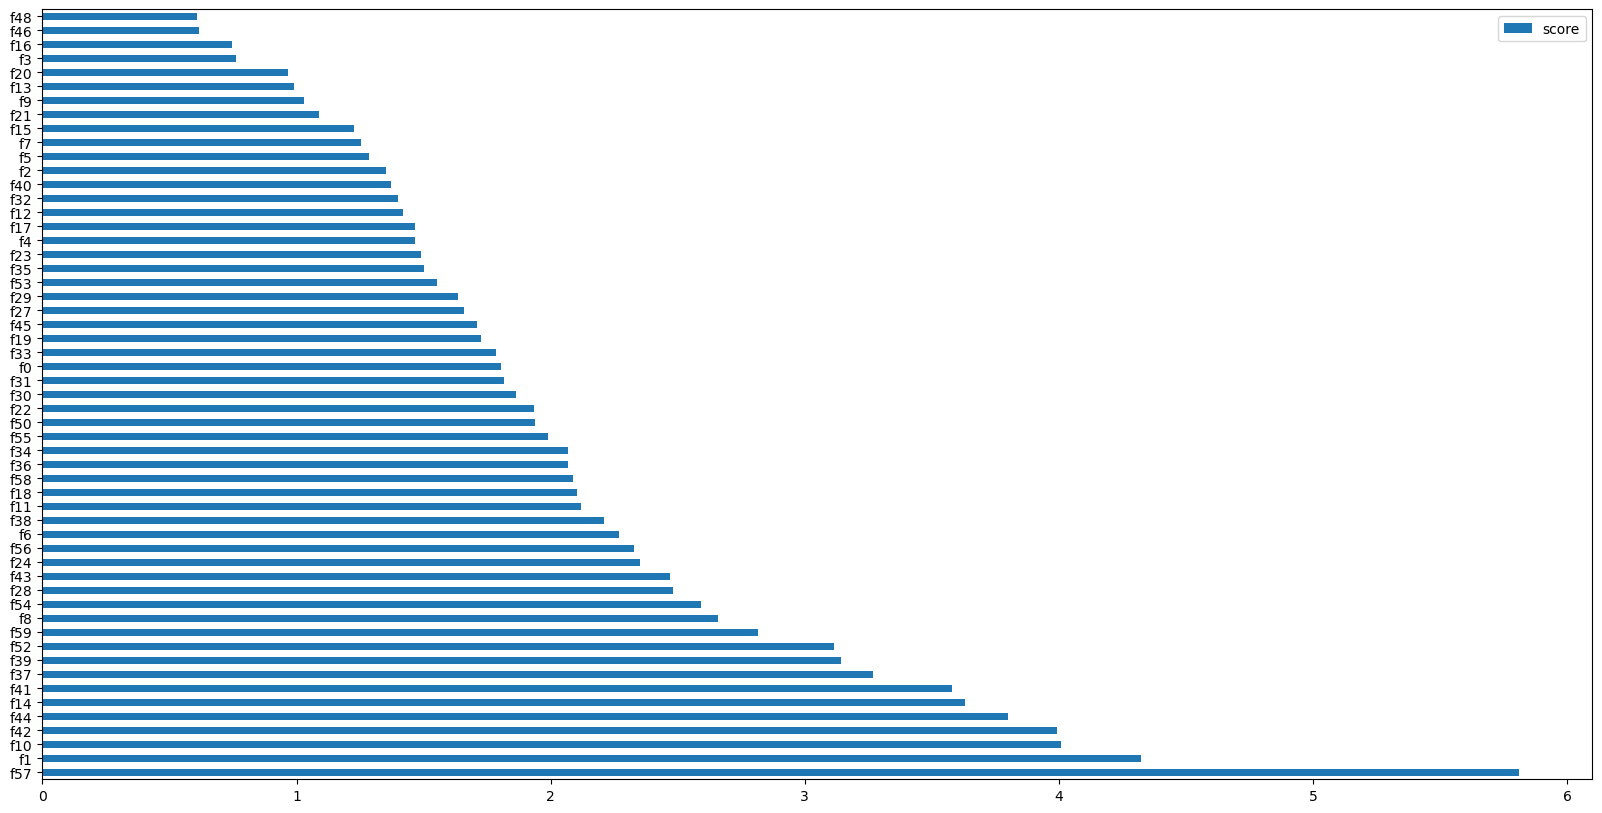

In [13]:
feature_important = pipeline['model'].get_booster().get_score(importance_type='gain')
keys = list(feature_important.keys())
values = list(feature_important.values())

data = pd.DataFrame(data=values, index=keys, columns=["score"]).sort_values(by = "score", ascending=False)
data.nlargest(60, columns="score").plot(kind='barh', figsize = (20,10)) 

In [14]:
for x in data.index:
    print(X_train.columns[int(x[1:])]) 

weekend_ratio
total_amount
credit_debit_ratio
category_26_mean
category_28_mean
monthly_std
category_25_mean
category_21_mean
category_23_mean
unique_txn_days
monthly_spend_trend
credit_sum
txn_per_day
category_12_mean
category_27_mean
category_8_mean
weekend_spending
median_amount
category_22_mean
recent30_sum
category_2_mean
large_txn_count
category_20_mean
category_18_mean
weekday_spending
category_34_mean
category_6_mean
category_14_mean
category_15_mean
total_balance
category_17_mean
category_3_mean
category_29_mean
category_11_mean
category_13_mean
txn_days_span
category_19_mean
category_7_mean
min_amount
category_1_mean
recent30_count
category_16_mean
category_24_mean
mean_amount
max_amount
transaction_count
monthly_cv
category_5_mean
debit_sum
monthly_mean
category_4_mean
std_amount
category_0_mean
category_30_mean
category_32_mean


In [15]:
trans_cats = pd.read_csv("transaction_categories.csv")
trans_cats

,code,description
0,0,SELF_TRANSFER
1,1,EXTERNAL_TRANSFER
2,2,DEPOSIT
3,3,PAYCHECK
4,4,MISCELLANEOUS
5,5,PAYCHECK_PLACEHOLDER
6,6,REFUND
7,7,INVESTMENT_INCOME
8,8,OTHER_BENEFITS
9,9,UNEMPLOYMENT_BENEFITS


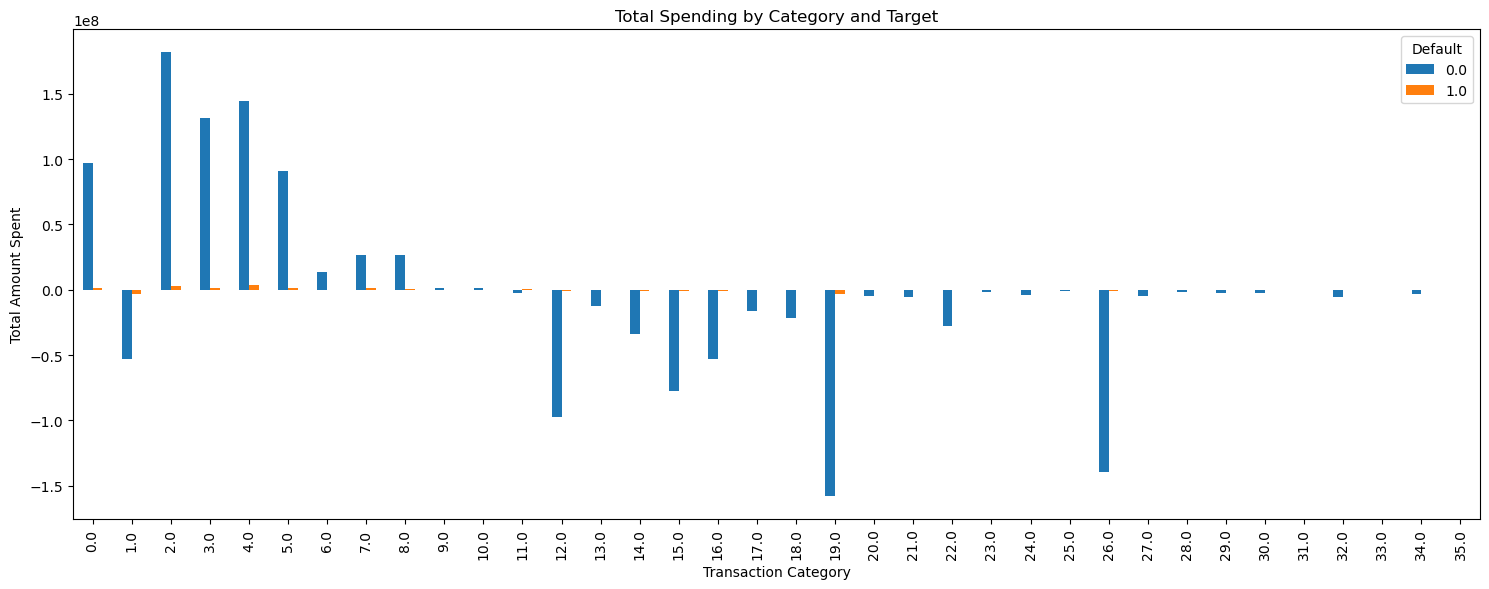

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge consumer_df with transaction_df
df = transactions_df.merge(consumer_df[['masked_consumer_id', 'FPF_TARGET']], on='masked_consumer_id')

# Total amount per category by target
category_summary = df.groupby(['category', 'FPF_TARGET'])['amount'].sum().unstack().fillna(0)
category_summary.plot(kind='bar', figsize=(15,6))
plt.title("Total Spending by Category and Target")
plt.xlabel("Transaction Category")
plt.ylabel("Total Amount Spent")
plt.legend(title="Default")
plt.tight_layout()
plt.show()


In [17]:
category_summary

FPF_TARGET,0.0,1.0
category,,
0.0,9.699944e+07,1127048.57
1.0,-5.277759e+07,-3433434.03
2.0,1.823034e+08,2853020.02
3.0,1.315014e+08,1263160.23
4.0,1.443807e+08,3831532.83
5.0,9.072719e+07,1337968.86
6.0,1.377716e+07,165428.35
7.0,2.661496e+07,966757.12
8.0,2.683338e+07,303422.97


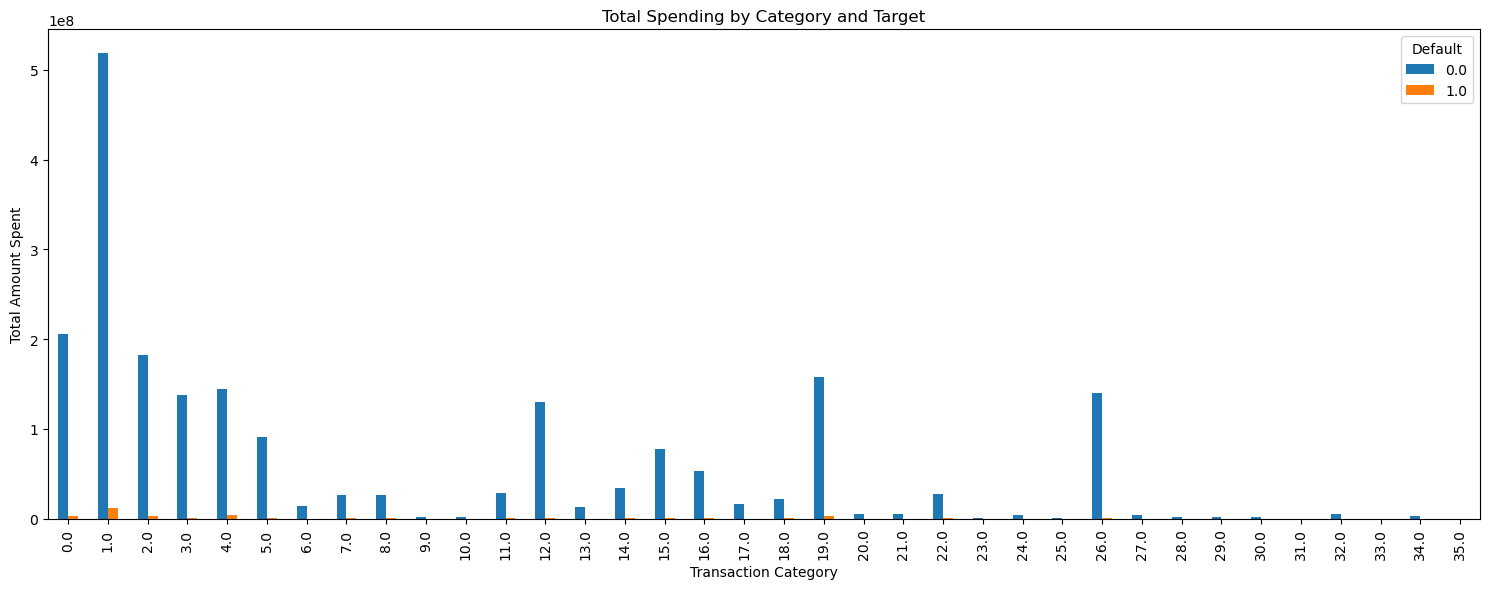

In [19]:
# category_summary_abs = df.groupby(['category', 'FPF_TARGET'])['amount'].abs().sum().unstack().fillna(0)
# Alternative way
category_summary_abs = df.groupby(['category', 'FPF_TARGET'])['amount'].agg(lambda x: x.abs().sum()).unstack().fillna(0)
category_summary_abs.plot(kind='bar', figsize=(15,6))
plt.title("Total Spending by Category and Target")
plt.xlabel("Transaction Category")
plt.ylabel("Total Amount Spent")
plt.legend(title="Default")
plt.tight_layout()
plt.show()

In [21]:
category_summary_abs.sort_values(by='category')

FPF_TARGET,0.0,1.0
category,,
0.0,2.053349e+08,2908492.75
1.0,5.190492e+08,12472528.57
2.0,1.823034e+08,2853020.02
3.0,1.380839e+08,1263203.43
4.0,1.443807e+08,3831532.83
5.0,9.072719e+07,1337968.86
6.0,1.377716e+07,165428.35
7.0,2.661496e+07,966757.12
8.0,2.683338e+07,303422.97
